In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [10]:
# Simulate plant disease dataset
IMG_SIZE = 64
NUM_CLASSES = 10
SAMPLES = 1000

np.random.seed(42)
X = np.random.random((SAMPLES, IMG_SIZE, IMG_SIZE, 3)).astype('float32')
y = np.random.randint(0, NUM_CLASSES, SAMPLES)

# Split
split = int(0.8 * SAMPLES)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

CLASS_NAMES = [f'Plant_Class_{i}' for i in range(NUM_CLASSES)]
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Classes: {NUM_CLASSES}")

Train: (800, 64, 64, 3), Val: (200, 64, 64, 3)
Classes: 10


In [11]:

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

 Trainable params: 1,275,722 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)
print("CNN Training Done!")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.1112 - loss: 2.3227 - val_accuracy: 0.1050 - val_loss: 2.3096
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1213 - loss: 2.2981 - val_accuracy: 0.1050 - val_loss: 2.3094
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1150 - loss: 2.2976 - val_accuracy: 0.0850 - val_loss: 2.3028
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1187 - loss: 2.3019 - val_accuracy: 0.1050 - val_loss: 2.3026
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0950 - loss: 2.2995 - val_accuracy: 0.1050 - val_loss: 2.3036
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1063 - loss: 2.2985 - val_accuracy: 0.1050 - val_loss: 2.3043
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1050 - loss: 2.2949 - val_accuracy: 0.1050 - val_loss: 2.3114
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1175 - loss: 2.2982 - val_accuracy: 0.1050 - v

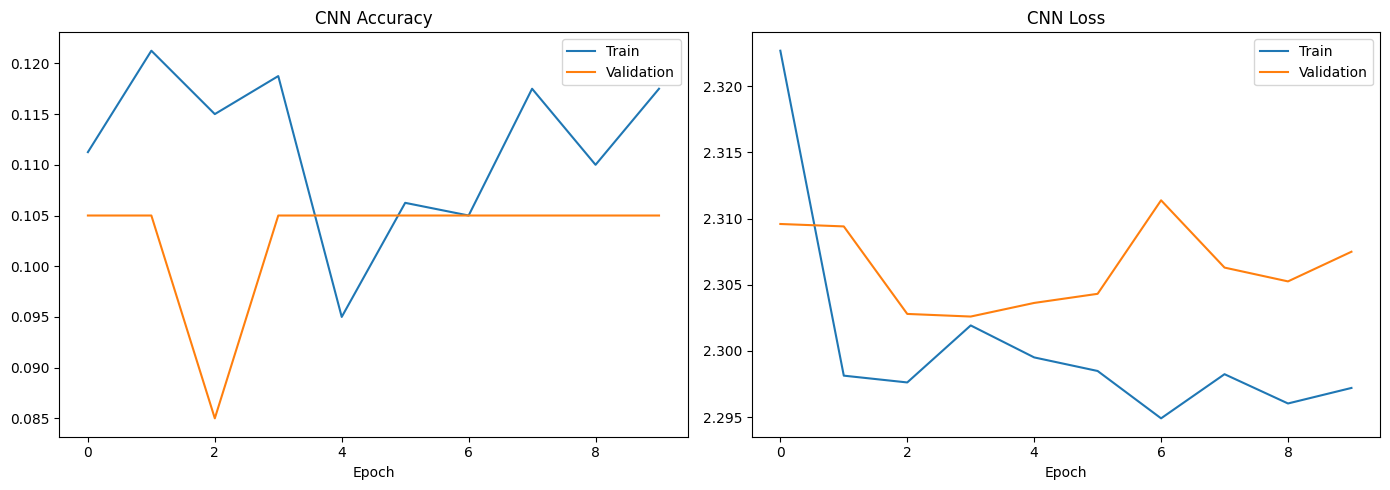

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_curves.png')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


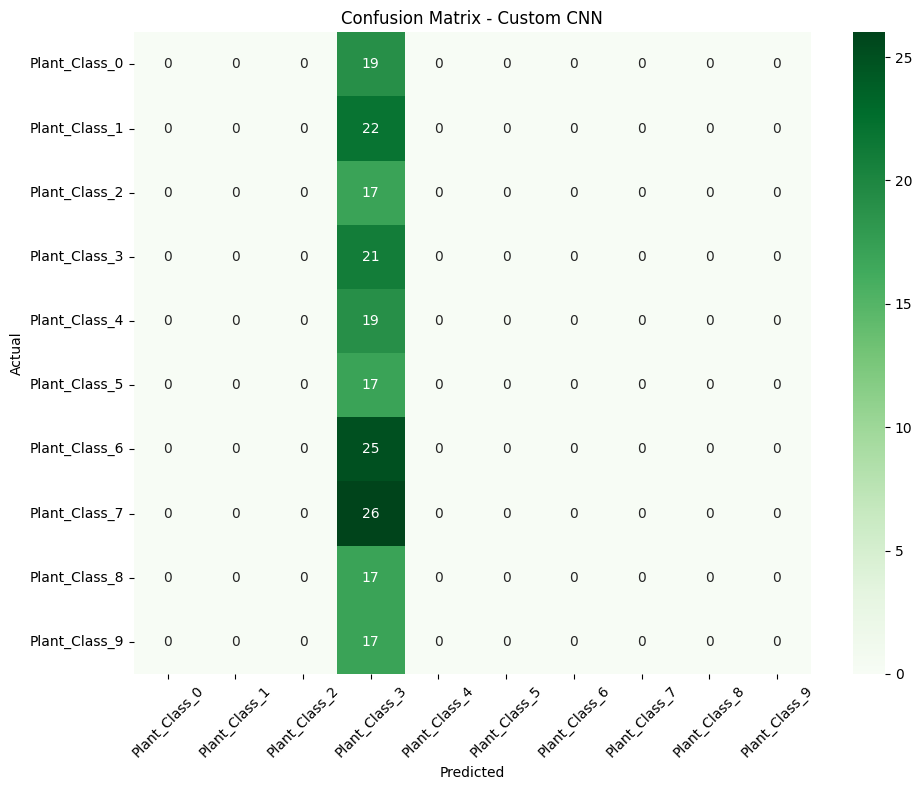

               precision    recall  f1-score   support

Plant_Class_0       0.00      0.00      0.00        19
Plant_Class_1       0.00      0.00      0.00        22
Plant_Class_2       0.00      0.00      0.00        17
Plant_Class_3       0.10      1.00      0.19        21
Plant_Class_4       0.00      0.00      0.00        19
Plant_Class_5       0.00      0.00      0.00        17
Plant_Class_6       0.00      0.00      0.00        25
Plant_Class_7       0.00      0.00      0.00        26
Plant_Class_8       0.00      0.00      0.00        17
Plant_Class_9       0.00      0.00      0.00        17

     accuracy                           0.10       200
    macro avg       0.01      0.10      0.02       200
 weighted avg       0.01      0.10      0.02       200



In [14]:
y_pred = np.argmax(model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Custom CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_val, y_pred,
      target_names=CLASS_NAMES))

In [15]:
base = MobileNetV2(weights=None,
                   include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
tl_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

tl_history = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)
print("MobileNetV2 Done!")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 294ms/step - accuracy: 0.1088 - loss: 2.5577 - val_accuracy: 0.1300 - val_loss: 2.3024
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1975 - loss: 2.2207 - val_accuracy: 0.1250 - val_loss: 2.3024
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3288 - loss: 1.9853 - val_accuracy: 0.0850 - val_loss: 2.3026
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3113 - loss: 1.9382 - val_accuracy: 0.0850 - val_loss: 2.3032
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3938 - loss: 1.8627 - val_accuracy: 0.1050 - val_loss: 2.3042
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3975 - loss: 1.8305 - val_accuracy: 0.0850 - val_loss: 2.3056
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4737 - loss: 1.6475 - val_accuracy: 0.0850 - val_loss: 2.3075
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5038 - loss: 1.4903 - val_accuracy: 0.0850 -

MODEL COMPARISON
Custom CNN:    10.50%
MobileNetV2:   13.00%


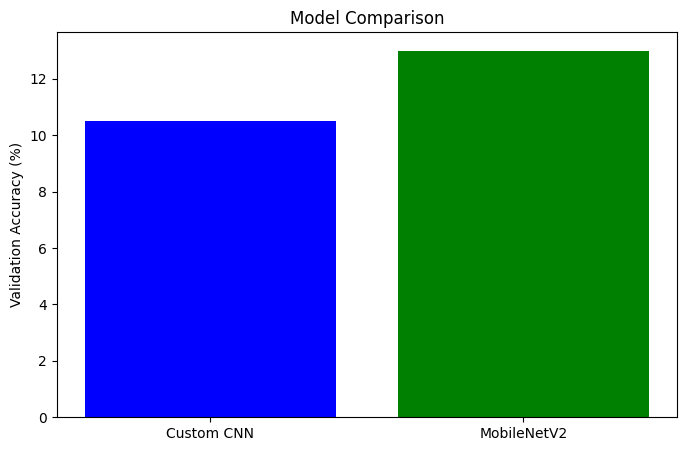

In [16]:
cnn_acc = max(history.history['val_accuracy'])
tl_acc = max(tl_history.history['val_accuracy'])

print("="*40)
print("MODEL COMPARISON")
print("="*40)
print(f"Custom CNN:    {cnn_acc*100:.2f}%")
print(f"MobileNetV2:   {tl_acc*100:.2f}%")
print("="*40)

# Plot comparison
models_names = ['Custom CNN', 'MobileNetV2']
accuracies = [cnn_acc*100, tl_acc*100]
plt.figure(figsize=(8, 5))
plt.bar(models_names, accuracies, color=['blue', 'green'])
plt.title('Model Comparison')
plt.ylabel('Validation Accuracy (%)')
plt.savefig('comparison.png')
plt.show()